<>:211: SyntaxWarning: invalid escape sequence '\m'
<>:211: SyntaxWarning: invalid escape sequence '\s'
<>:211: SyntaxWarning: invalid escape sequence '\m'
<>:211: SyntaxWarning: invalid escape sequence '\s'
/var/folders/5d/9l6gb_c515qgg88vn1bg1y340000gn/T/ipykernel_58777/282325528.py:211: SyntaxWarning: invalid escape sequence '\m'
  'r-', linewidth=3, label=f'MLE Fit ($\mu$={mu_mle:.2f}, $\sigma$={sigma_mle:.2f})')
/var/folders/5d/9l6gb_c515qgg88vn1bg1y340000gn/T/ipykernel_58777/282325528.py:211: SyntaxWarning: invalid escape sequence '\s'
  'r-', linewidth=3, label=f'MLE Fit ($\mu$={mu_mle:.2f}, $\sigma$={sigma_mle:.2f})')


--- STATISTICS BY MONTH ---
           daily_sleep_hours             daily_rem_hours            
                        mean   std count            mean   std count
year_month                                                          
2024-11                 7.30  1.23    29            1.90  0.59    29
2024-12                 7.10  1.12    26            1.72  0.40    26
2025-01                 6.73  1.30    15            1.66  0.56    15
2025-02                 6.81  0.80     8            1.65  0.35     8
2025-03                 7.14  0.54     4            1.98  0.30     4
2025-04                 6.61  0.81    20            1.54  0.38    20
2025-05                 6.58  0.84    19            1.47  0.44    19
2025-06                 6.84  0.58    18            1.70  0.44    18
2025-07                 6.74  0.51    21            1.75  0.24    21
2025-08                 6.58  1.10    20            1.64  0.53    20
2025-09                 7.30  1.17    18            1.77  0.48    18
2025-1

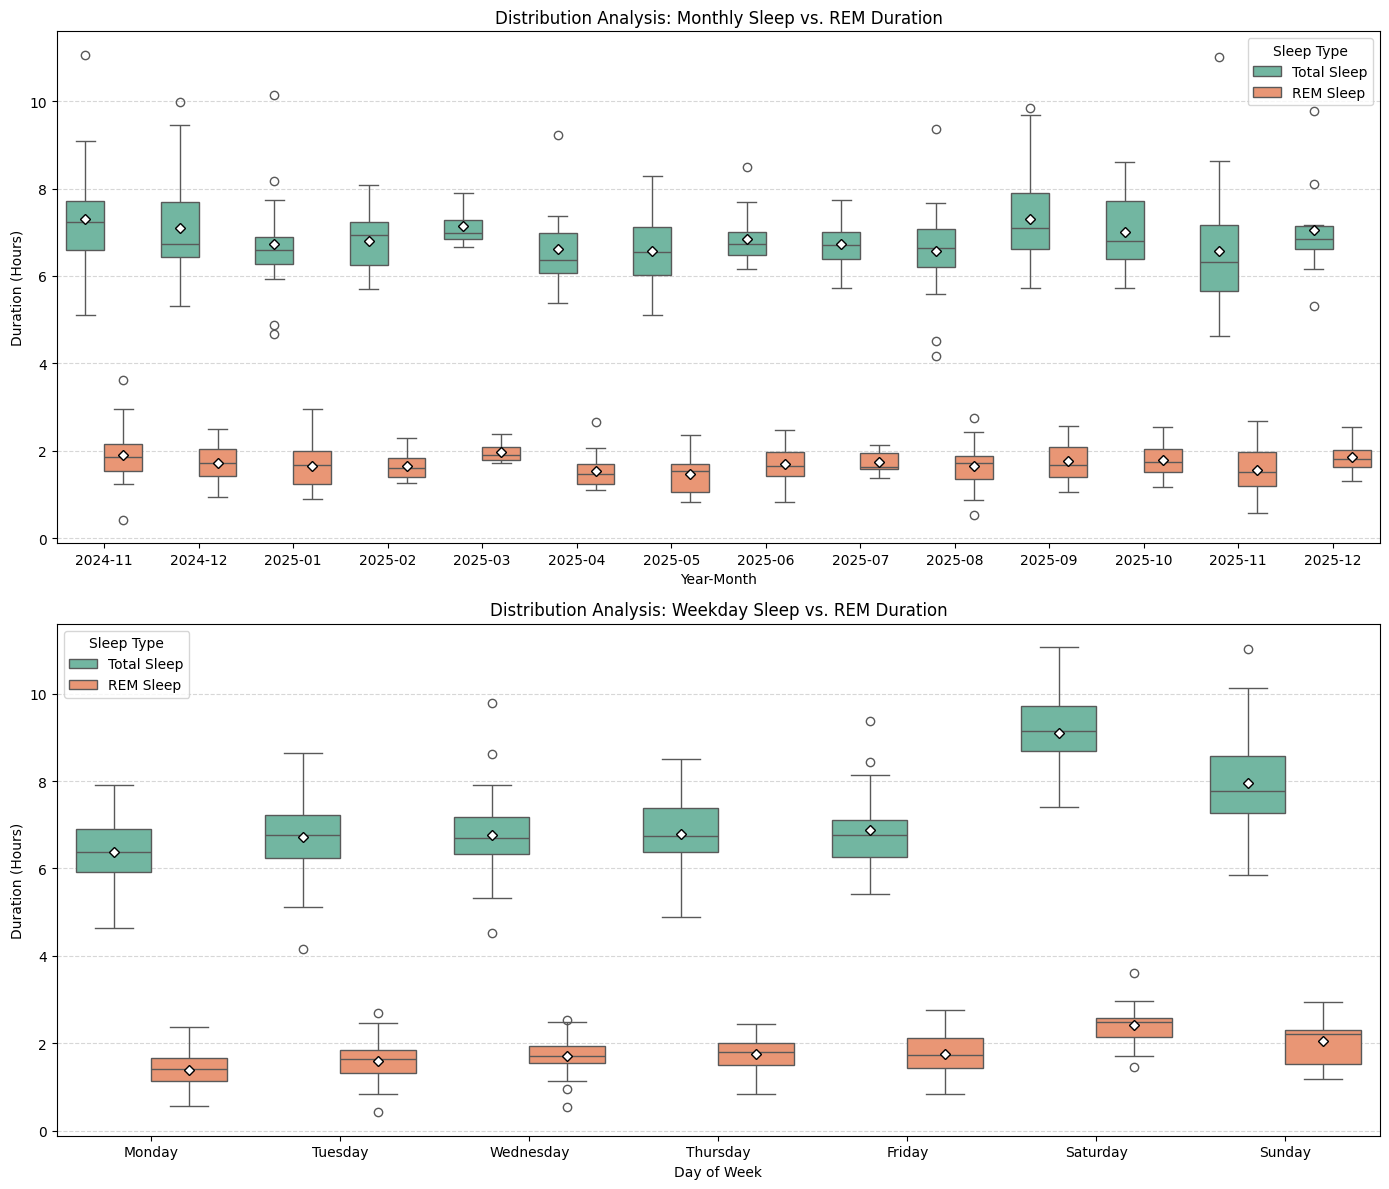

--- STEP STATISTICS BY WEEKDAY ---
           count         mean          std
day_name                                  
Monday        62  8754.290323  2923.822270
Tuesday       62  9738.951613  4277.613044
Wednesday     63  9264.492063  3830.863420
Thursday      63  9315.571429  3063.628124
Friday        63  9580.619048  3267.431296
Saturday      62  7059.306452  5829.684736
Sunday        61  2457.852459  4814.020004


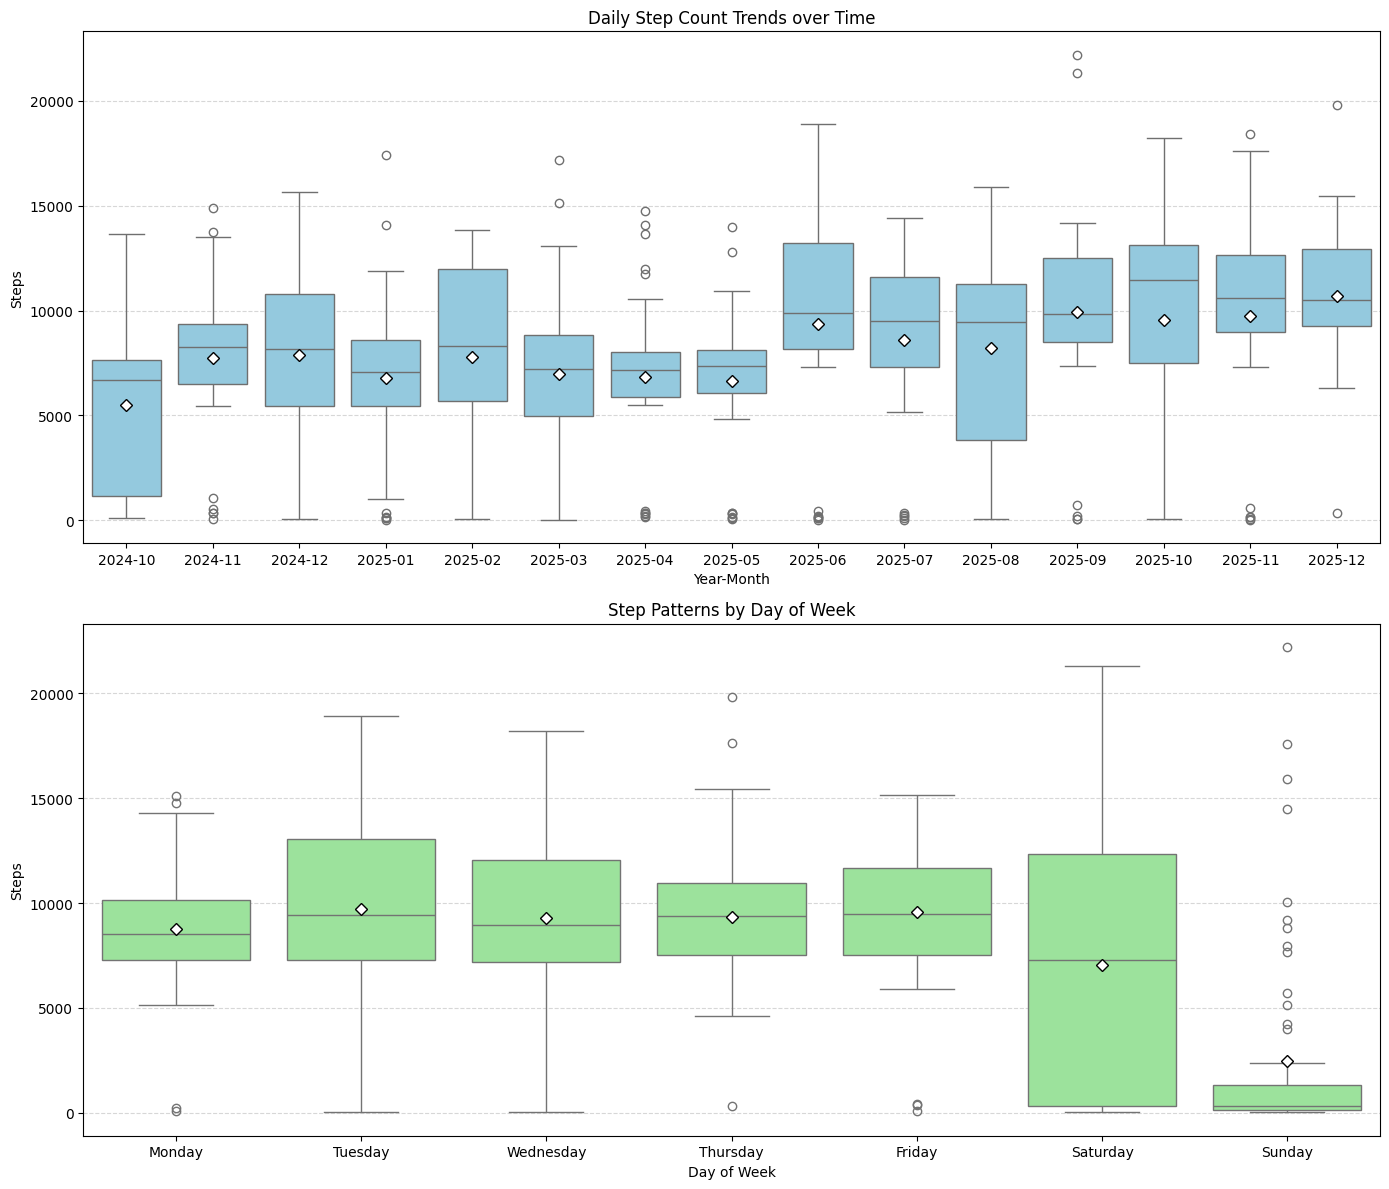

       daily_sleep_hours  daily_rem_hours         count
count         247.000000       247.000000    247.000000
mean            6.892375         1.702294   8093.769231
std             1.048232         0.472170   4893.965291
min             4.166667         0.416667     18.000000
25%             6.266667         1.416667   5838.500000
50%             6.750000         1.700000   8491.000000
75%             7.283333         1.991667  11361.000000
max            11.066667         3.616667  22202.000000
                   daily_sleep_hours  daily_rem_hours     count
daily_sleep_hours           1.000000         0.789300  0.161003
daily_rem_hours             0.789300         1.000000  0.237402
count                       0.161003         0.237402  1.000000
Skewness: 0.9462
Kurtosis: 2.2096


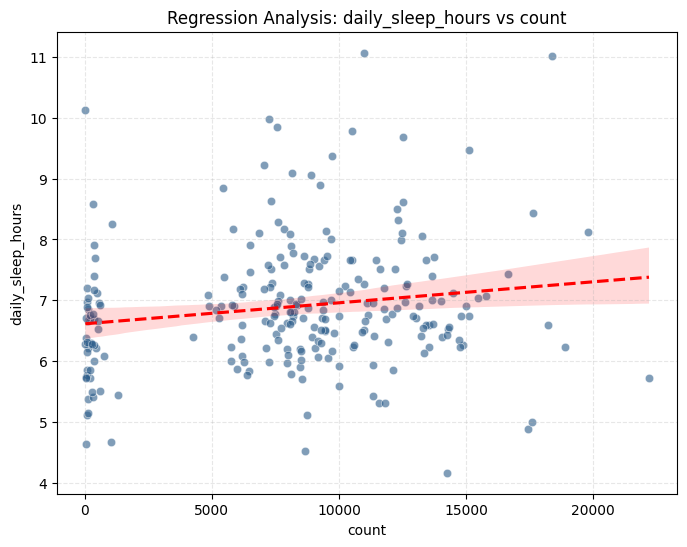

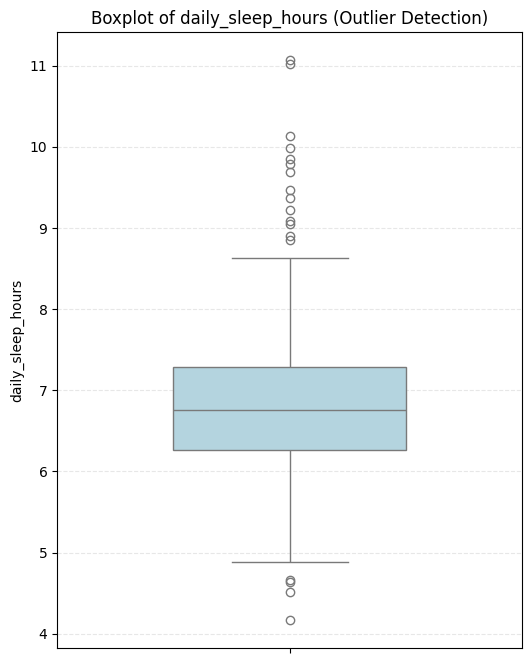

--- PARAMETER ESTIMATION (daily_sleep_hours) ---
MLE: mu=6.8924, sigma=1.0461
MoM: mu=6.8924, sigma=1.0461
Bayesian Estimate: mu=6.7985 (Prior: mu=1.5, tau=0.5)


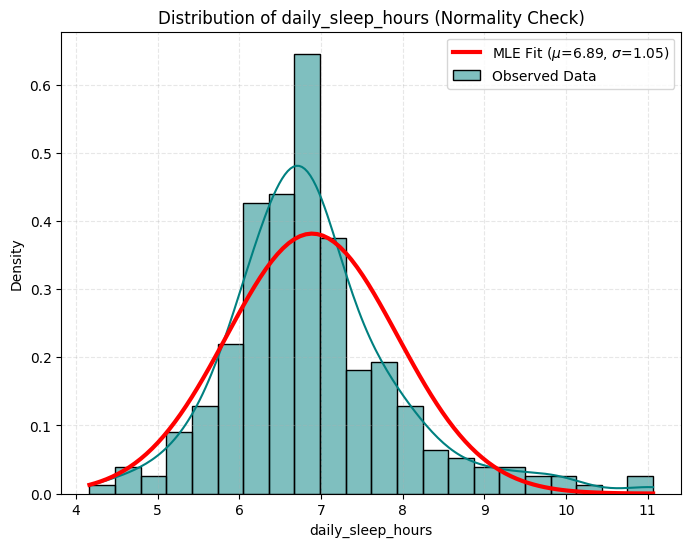


--- GOODNESS OF FIT (KS TEST) ---
Statistic=0.1073, P-Value=0.0062

--- HYPOTHESIS TESTING (Benchmark = 1.5) ---
Result: Data does NOT look Normal (p < 0.05). Using Nonparametric Test (Wilcoxon).
Wilcoxon Signed-Rank Test: Statistic=0.0000, P-Value=0.0000

--- REGRESSION RESULTS ---
                            OLS Regression Results                            
Dep. Variable:      daily_sleep_hours   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     6.520
Date:                Sun, 14 Dec 2025   Prob (F-statistic):             0.0113
Time:                        20:25:27   Log-Likelihood:                -358.37
No. Observations:                 247   AIC:                             720.7
Df Residuals:                     245   BIC:                             727.8
Df Model:                           1                                         
Cova

In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

PATH = 'data'
sleep = pd.read_csv(f"{PATH}/sleep12.csv", skiprows=1, index_col=False, on_bad_lines='skip')
sleep = sleep.rename(columns={'com.samsung.health.sleep.end_time': 'date'})
sleep = sleep.loc[:, ~sleep.columns.str.contains('^Unnamed')]
sleep['date'] = pd.to_datetime(sleep['date']).dt.normalize()
sleep = sleep[(sleep['date'] > pd.to_datetime('2024-10-01')) & (sleep['sleep_duration'] > 0)] 

steps = pd.read_csv(f"{PATH}/steps12.csv", skiprows=2, index_col=False)
steps = steps.loc[:, ~steps.columns.str.contains('^Unnamed')]
steps['update_time'] = pd.to_datetime(steps['update_time']).dt.normalize()
steps = steps[steps['update_time'] > pd.to_datetime('2024-10-01')] # To match the sleep dates

daily_steps = steps.groupby('update_time')['count'].max().reset_index() 
daily_sleep = sleep.groupby('date')[['sleep_duration', 'total_rem_duration']].sum().reset_index()
daily_sleep['daily_sleep_hours'] = daily_sleep['sleep_duration'] / 60 
daily_sleep['daily_rem_hours'] = daily_sleep['total_rem_duration'] / 60

daily_sleep['year_month'] = daily_sleep['date'].dt.to_period('M').astype(str)
daily_sleep['day_name'] = daily_sleep['date'].dt.day_name()
daily_sleep = daily_sleep.sort_values('date')

# Quantifying mean and stddev of sleep patterns.
stats_month = daily_sleep.groupby('year_month')[['daily_sleep_hours', 'daily_rem_hours']].agg(['mean', 'std', 'count']).round(2)
print("--- STATISTICS BY MONTH ---")
print(stats_month)

# Reindexing ensuring we follow the temporal cycle of the week, not alphabetical order.
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

stats_day = daily_sleep.groupby('day_name')[['daily_sleep_hours', 'daily_rem_hours']]\
    .agg(['count', 'mean', 'std'])\
    .reindex(day_order)\
    .round(2)

print("--- STATISTICS BY WEEKDAY ---")
print(stats_day)


# Melting the dataframe to long format. 
# This allows us to plot both "Total Sleep" and "REM Sleep" on the same Y-axis scale to visually compare their variances side by side.
df_melted = daily_sleep.melt(
    id_vars=['date', 'year_month', 'day_name'], 
    value_vars=['daily_sleep_hours', 'daily_rem_hours'],
    var_name='Sleep Type', 
    value_name='Duration (Hours)'
)

df_melted['Sleep Type'] = df_melted['Sleep Type'].replace({
    'daily_sleep_hours': 'Total Sleep', 
    'daily_rem_hours': 'REM Sleep'
})

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Monthly Distribution
sns.boxplot(
    data=df_melted, 
    x='year_month', 
    y='Duration (Hours)', 
    hue='Sleep Type', 
    palette="Set2", 
    ax=axes[0], 
    showmeans=True, 
    dodge=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":5}
)
axes[0].set_title('Distribution Analysis: Monthly Sleep vs. REM Duration')
axes[0].set_xlabel('Year-Month')
axes[0].set_ylabel('Duration (Hours)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Weekday Distribution
sns.boxplot(
    data=df_melted, 
    x='day_name', 
    y='Duration (Hours)', 
    hue='Sleep Type', 
    order=day_order, 
    palette="Set2", 
    ax=axes[1], 
    showmeans=True,
    dodge=True,
    meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":5}
)
axes[1].set_title('Distribution Analysis: Weekday Sleep vs. REM Duration')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Duration (Hours)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('distribution_stats_analysis.png', dpi=300)
plt.show()

daily_steps['year_month'] = daily_steps['update_time'].dt.to_period('M').astype(str)
daily_steps['day_name'] = daily_steps['update_time'].dt.day_name()
daily_steps = daily_steps.sort_values('update_time')


day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
stats_steps = daily_steps.groupby('day_name')['count'].agg(['count', 'mean', 'std']).reindex(day_order)

print("--- STEP STATISTICS BY WEEKDAY ---")
print(stats_steps)

# --- 3. VISUALIZATION ---
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Monthly Steps
sns.boxplot(data=daily_steps, x='year_month', y='count', 
            color='skyblue', ax=axes[0], showmeans=True,
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":6})
axes[0].set_title('Daily Step Count Trends over Time')
axes[0].set_ylabel('Steps')
axes[0].set_xlabel('Year-Month')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Weekday Steps
sns.boxplot(data=daily_steps, x='day_name', y='count', 
            order=day_order, color='lightgreen', ax=axes[1], showmeans=True,
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":6})
axes[1].set_title('Step Patterns by Day of Week')
axes[1].set_ylabel('Steps')
axes[1].set_xlabel('Day of Week')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('step_analysis.png', dpi=300)
plt.show()

daily_steps['join_date'] = daily_steps['update_time'] + pd.Timedelta(days=1) # So that I can join them as tomorrow's date.

merged_df = pd.merge(
    daily_sleep, 
    daily_steps[['join_date', 'count']], 
    left_on='date', 
    right_on='join_date',
    how='inner' # if there's no match, I don't want them
)

df = merged_df.dropna(subset=['daily_sleep_hours', 'daily_rem_hours', 'count']) # if there's any missing values, I don't want them either

print(df[['daily_sleep_hours', 'daily_rem_hours', 'count']].describe())
print(df[['daily_sleep_hours', 'daily_rem_hours', 'count']].corr())

X = 'count'
Y = 'daily_sleep_hours'

skewness = stats.skew(df[Y])
kurt = stats.kurtosis(df[Y])
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurt:.4f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(x=df[X], y=df['daily_sleep_hours'], alpha=0.6, color='#2b5c8a')
sns.regplot(x=df[X], y=df['daily_sleep_hours'], scatter=False, color='red', line_kws={'linestyle':'--'})
plt.title(f'Regression Analysis: {Y} vs {X}')
plt.xlabel(X)
plt.ylabel(Y)
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig(f'scatter_{Y}_vs_{X}.png', dpi=300, bbox_inches='tight')
plt.show()

plt.figure(figsize=(6, 8))
sns.boxplot(y=df[Y], color='lightblue', width=0.5)
plt.title(f'Boxplot of {Y} (Outlier Detection)')
plt.ylabel(Y)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.savefig(f'boxplot_{Y}.png', dpi=300, bbox_inches='tight')
plt.show()

# PARAMETER ESTIMATION

# Maximum Likelihood Estimation (MLE)
data = df[Y]
mu_mle, sigma_mle = stats.norm.fit(data)

# Method of Moment (MoM)
# For normal distribution, MoM is simply sample mean and population stddev
mu_mom = data.mean()
sigma_mom = data.std(ddof=0)

# Bayesian Estimation
mu_0 = 1.5      
tau = 0.5       
n = len(data)

# Bayesian Update for Mean
var_data = sigma_mle**2
var_prior = tau**2
weight_prior = var_data / (n * var_prior + var_data)
weight_data = (n * var_prior) / (n * var_prior + var_data)
mu_bayes = weight_prior * mu_0 + weight_data * data.mean()

print(f"--- PARAMETER ESTIMATION ({Y}) ---")
print(f"MLE: mu={mu_mle:.4f}, sigma={sigma_mle:.4f}")
print(f"MoM: mu={mu_mom:.4f}, sigma={sigma_mom:.4f}")
print(f"Bayesian Estimate: mu={mu_bayes:.4f} (Prior: mu={mu_0}, tau={tau})")

plt.figure(figsize=(8, 6))
sns.histplot(data, stat="density", kde=True, color='teal', label='Observed Data')

x_range = np.linspace(data.min(), data.max(), 100)
plt.plot(x_range, stats.norm.pdf(x_range, mu_mle, sigma_mle), 
         'r-', linewidth=3, label=f'MLE Fit ($\mu$={mu_mle:.2f}, $\sigma$={sigma_mle:.2f})')

plt.title(f'Distribution of {Y} (Normality Check)')
plt.xlabel(Y)
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)

plt.savefig(f'dist_{Y}_MLE.png', dpi=300, bbox_inches='tight')
plt.show()

# GOODNESS OF FIT & HYPOTHESIS TESTING ---

ks_stat, ks_p = stats.kstest(data, 'norm', args=(mu_mle, sigma_mle))
print(f"\n--- GOODNESS OF FIT (KS TEST) ---")
print(f"Statistic={ks_stat:.4f}, P-Value={ks_p:.4f}")

# Conditional Hypothesis Testing 
HYPOTHESIS_BENCHMARK = 1.5
print(f"\n--- HYPOTHESIS TESTING (Benchmark = {HYPOTHESIS_BENCHMARK}) ---")
alpha = 0.05

if ks_p > alpha:
    print(f"Result: Data looks Normal (p > {alpha}). Using Parametric Test (T-Test).")
    t_stat, t_p = stats.ttest_1samp(data, HYPOTHESIS_BENCHMARK)
    print(f"One-Sample T-Test: Statistic={t_stat:.4f}, P-Value={t_p:.4f}")
else:
    print(f"Result: Data does NOT look Normal (p < {alpha}). Using Nonparametric Test (Wilcoxon).")
    # As Wilcoxon Signed Rank Test is the nonparametric alternative to one sample t-test
    w_stat, w_p = stats.wilcoxon(data - HYPOTHESIS_BENCHMARK)
    print(f"Wilcoxon Signed-Rank Test: Statistic={w_stat:.4f}, P-Value={w_p:.4f}")

# --- 5. REGRESSION ANALYSIS ---
X = sm.add_constant(df[X])
Y = df[Y]
model = sm.OLS(Y, X).fit()

print("\n--- REGRESSION RESULTS ---")
print(model.summary())